In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
original_df=pd.read_csv("test_df_with_usd_login.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.shape

(4461, 15)

In [5]:
df.columns

Index(['company_size', 'is_premium', 'subscription_status',
       'jobma_catcher_status', 'sub_users', 'wallet_amount', 'is_unlimited',
       'plan_type', 'subscription_count', 'invitations',
       'pre_recorded_kit_counts', 'number_of_jobs_posted',
       'pre_rec_interview_taken', 'subscription_amount_usd',
       'days_since_login'],
      dtype='object')

In [6]:
df.isna().sum()

company_size               0
is_premium                 0
subscription_status        0
jobma_catcher_status       0
sub_users                  0
wallet_amount              0
is_unlimited               0
plan_type                  0
subscription_count         0
invitations                0
pre_recorded_kit_counts    0
number_of_jobs_posted      0
pre_rec_interview_taken    0
subscription_amount_usd    0
days_since_login           0
dtype: int64

In [7]:
df.nunique()

company_size                 5
is_premium                   2
subscription_status          2
jobma_catcher_status         2
sub_users                   19
wallet_amount              179
is_unlimited                 2
plan_type                    2
subscription_count          34
invitations                126
pre_recorded_kit_counts     57
number_of_jobs_posted       51
pre_rec_interview_taken     89
subscription_amount_usd    707
days_since_login           736
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4461 entries, 0 to 4460
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4461 non-null   object 
 1   is_premium               4461 non-null   int64  
 2   subscription_status      4461 non-null   int64  
 3   jobma_catcher_status     4461 non-null   int64  
 4   sub_users                4461 non-null   int64  
 5   wallet_amount            4461 non-null   float64
 6   is_unlimited             4461 non-null   int64  
 7   plan_type                4461 non-null   int64  
 8   subscription_count       4461 non-null   int64  
 9   invitations              4461 non-null   int64  
 10  pre_recorded_kit_counts  4461 non-null   int64  
 11  number_of_jobs_posted    4461 non-null   int64  
 12  pre_rec_interview_taken  4461 non-null   int64  
 13  subscription_amount_usd  4461 non-null   float64
 14  days_since_login        

In [9]:
df

,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login
0,1-25,0,1,1,1,66666.0,1,0,1,4,2,1,1,176.5,377
1,26-100,0,2,1,0,60.0,0,1,1,0,0,0,0,0.6,439
2,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,1.4,439
3,26-100,0,1,1,0,50.0,0,1,3,0,0,1,0,178.8,439
4,26-100,0,2,1,0,60.0,0,1,1,0,0,1,0,138.8,1794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4456,1-25,0,1,1,0,35.0,0,0,1,3,1,2,3,1.2,329
4457,1-25,0,1,1,0,147.0,0,0,1,3,3,5,1,0.0,329
4458,26-100,0,1,1,0,50.0,0,0,1,0,0,0,0,1.2,328
4459,1-25,0,1,1,0,49.0,0,0,1,2,2,2,1,0.0,327


In [10]:
binary_columns = ['is_premium',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]

categorical_columns = ['company_size']
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken',
                   'days_since_login']

ordinal_columns =['subscription_amount_usd']

In [11]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [12]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [13]:
# pipeline

In [14]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4461, 19])

In [15]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [16]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20
batch_size = 16

In [17]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/20, Loss: 0.0741
Epoch 4/20, Loss: 0.0707
Epoch 6/20, Loss: 0.0638
Epoch 8/20, Loss: 0.0578
Epoch 10/20, Loss: 0.0475
Epoch 12/20, Loss: 0.0532
Epoch 14/20, Loss: 0.0393
Epoch 16/20, Loss: 0.0292
Epoch 18/20, Loss: 0.0312
Epoch 20/20, Loss: 0.0281


In [18]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4461, 32)

In [19]:
type(embeddings_np), embeddings.shape

(numpy.ndarray, torch.Size([4461, 32]))

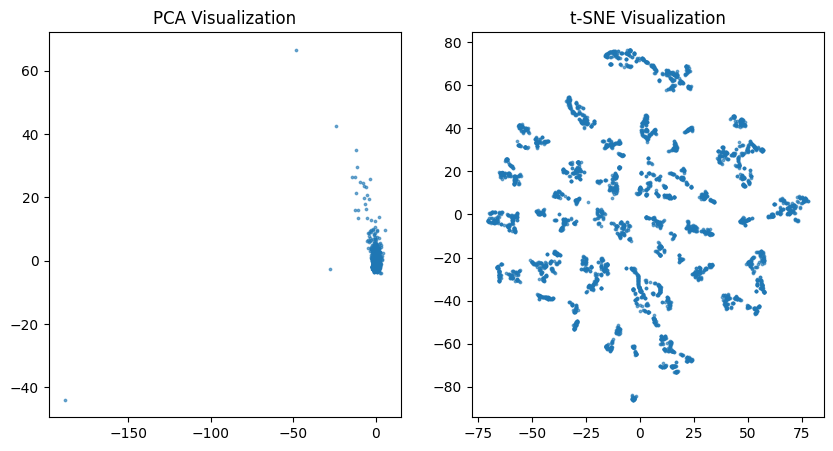

In [20]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()

# Visualisation

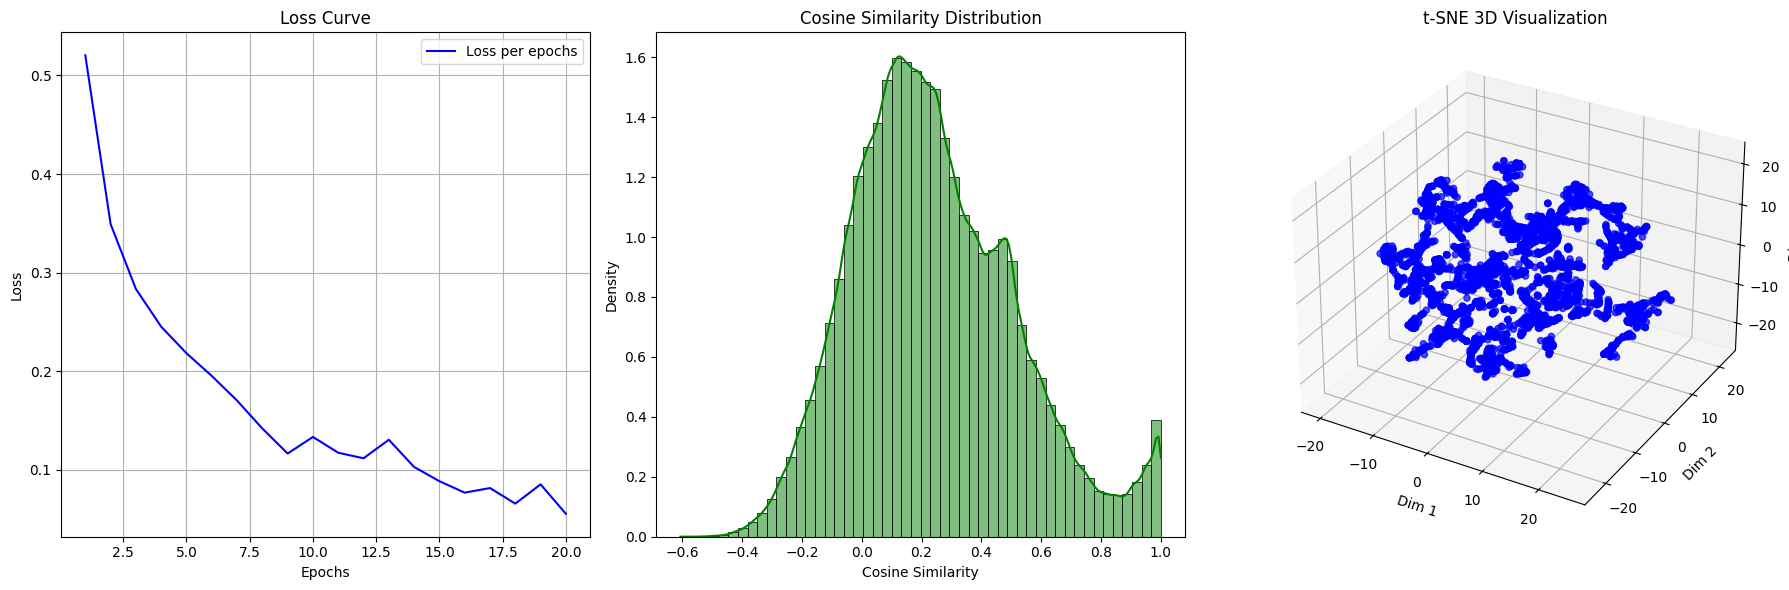

In [21]:
#Loss Curve
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Loss per epochs', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

#Cosine Similarity Histogram
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

#t-SNE in 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c='blue', alpha=0.7)
ax3.set_title('t-SNE 3D Visualization')
ax3.set_xlabel('Dim 1')
ax3.set_ylabel('Dim 2')
ax3.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

# Similarity

In [83]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
        
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [72]:
original_df.max().to_dict()

{'jobma_catcher_id': 10536,
 'company_size': 'More than 1000',
 'is_premium': 1,
 'subscription_status': 2,
 'jobma_catcher_status': 1,
 'sub_users': 40,
 'wallet_amount': 4995968.0,
 'is_unlimited': 1,
 'plan_type': 1,
 'subscription_count': 116,
 'invitations': 50046,
 'pre_recorded_kit_counts': 292,
 'number_of_jobs_posted': 189,
 'pre_rec_interview_taken': 635,
 'subscription_amount_usd': 1398501.6,
 'days_since_login': 1794}

In [24]:
sample_dict={'company_size': '101-500',
             'is_premium': 0,
             'subscription_status': 2,
             'jobma_catcher_status': 1,
             'sub_users': 0,
             'wallet_amount': 50.0,
             'is_unlimited': 1,
             'plan_type': 0,
             'subscription_count': 1,
             'invitations': 0,
             'pre_recorded_kit_counts': 2,
             'number_of_jobs_posted': 2,
             'pre_rec_interview_taken': 1,
             'subscription_amount_usd': 208.2,
            'days_since_login':376 }

In [25]:
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,8054,101-500,0,1,1,0,60.0,1,0,2,0,0,0,0,235.2,1001,0.984028
1,8487,101-500,0,1,1,0,60.0,1,0,2,0,1,1,0,235.2,912,0.982875
2,8201,101-500,0,1,1,0,60.0,1,0,2,1,1,0,1,235.2,980,0.982868
3,7715,101-500,0,2,1,0,60.0,1,0,2,0,0,0,0,124.7,1035,0.981178
4,8470,101-500,0,2,1,0,60.0,1,0,1,0,0,0,0,117.6,915,0.980688


In [26]:
sample_dict2 = { 'company_size': '101-500',
                 'is_premium': 0,
                 'subscription_status': 2,
                 'jobma_catcher_status': 1,
                 'sub_users': 0,
                 'wallet_amount': 60,
                 'is_unlimited': 0,
                 'plan_type': 0,
                 'subscription_count': 8,
                 'invitations': 25,
                 'pre_recorded_kit_counts': 3,
                 'number_of_jobs_posted': 5,
                 'pre_rec_interview_taken': 0,
                 'subscription_amount_usd': 118.8,
                 'days_since_login': 1086}

In [27]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,5034,101-500,0,2,1,0,60.0,0,0,8,0,0,0,0,12.5,1462,0.932590
1,7500,101-500,0,1,1,1,3735.0,0,0,9,0,1,2,0,171.4,1036,0.919137
2,6849,101-500,0,1,1,1,60.0,0,0,17,0,0,0,0,88.3,1086,0.914646
3,5654,101-500,0,2,1,1,60.0,0,0,6,1,0,0,0,28.1,1343,0.913658
4,6712,101-500,0,2,1,1,60.0,0,0,7,4,1,1,4,12.6,1092,0.874334


In [28]:
sample_dict3 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 66,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations': 5,
                'pre_recorded_kit_counts':5 ,
                'number_of_jobs_posted': 5,
                'pre_rec_interview_taken': 10,
                'subscription_amount_usd': 118.8,
                'days_since_login':1000}

In [43]:
recommend_from_sample_dict(sample_dict3, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,5644,26-100,0,2,1,0,60.0,1,0,4,0,0,0,0,71.6,1359,0.895926
1,5358,26-100,0,2,1,1,60.0,1,0,7,1,1,1,0,477.2,1393,0.892972
2,7933,26-100,0,1,1,1,60.0,1,0,5,0,0,0,0,126.5,1021,0.888929
3,4562,26-100,0,2,1,0,60.0,1,0,5,0,0,0,0,11.3,1561,0.882648
4,5465,26-100,0,2,1,0,60.0,1,0,3,4,1,1,0,118.5,1387,0.879631


In [30]:
sample_dict4 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 3,
                'invitations': 4,
                'pre_recorded_kit_counts': 1,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_amount_usd': 118.5,
                'days_since_login': 1568}

In [42]:
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,3828,26-100,0,2,1,0,60.0,1,0,3,0,0,0,0,3.5,1674,0.852810
1,4562,26-100,0,2,1,0,60.0,1,0,5,0,0,0,0,11.3,1561,0.850213
2,5080,26-100,0,2,1,1,60.0,1,0,2,0,0,0,0,2.4,1458,0.831985
3,5242,26-100,0,2,1,1,60.0,1,0,1,0,0,0,0,2.3,1452,0.825264
4,4954,26-100,0,2,1,0,60.0,1,0,2,0,0,0,0,3.5,1471,0.817963


In [32]:
sample_dict5 = {'company_size': '1-25',
                'is_premium': 0,
                'subscription_status': 1,
                'jobma_catcher_status': 1,
                'sub_users': 1,
                'wallet_amount': 66.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 1,
                'invitations': 4,
                'pre_recorded_kit_counts': 2,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 1,
                'subscription_amount_usd': 176.5,
                'days_since_login': 418
               }

In [41]:
recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,7336,1-25,0,2,1,0,60.0,1,0,2,0,0,0,0,235.2,1064,0.917731
1,7872,1-25,0,1,1,0,60.0,1,0,2,0,0,0,0,235.2,1027,0.916753
2,7792,1-25,0,2,1,0,60.0,1,0,1,0,0,0,0,235.3,1029,0.910961
3,5585,1-25,0,2,1,0,60.0,1,0,4,0,0,1,0,585.8,1349,0.910326
4,7524,1-25,0,1,1,0,60.0,1,0,1,0,0,0,0,470.6,1045,0.909877


In [57]:
original_df[original_df['jobma_catcher_id'] == 6227]

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login
2107,6227,500-1000,1,2,1,11,60.0,0,1,2,96,19,14,54,694.2,1090


In [34]:
sample_dict6 = {'company_size': '500-1000',
                'is_premium': 1,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 11,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 2,
                'invitations': 96,
                'pre_recorded_kit_counts': 19,
                'number_of_jobs_posted': 14,
                'pre_rec_interview_taken': 54,
                'subscription_amount_usd': 694.2,
                'days_since_login': 1090,
               }

In [90]:
recommend_from_sample_dict(sample_dict6, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,6227,500-1000,1,2,1,11,60.0,0,1,2,96,19,14,54,694.2,1090,0.943700
1,8334,500-1000,1,1,1,13,60.0,0,0,4,0,0,0,0,55.4,944,0.857492
2,6042,26-100,1,2,1,10,60.0,0,0,4,11,2,3,3,11.8,1092,0.800707
3,8609,101-500,1,1,1,13,180.0,0,1,2,7,3,5,2,641.2,399,0.800233
4,6017,500-1000,1,1,1,10,1860.0,0,0,11,15,6,9,5,56.7,467,0.799464


In [51]:
sample_dict7 = {'company_size': '101-500',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 150.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_count': 1,
                'invitations':24,
                'pre_recorded_kit_counts': 10,
                'number_of_jobs_posted': 15,
                'pre_rec_interview_taken': 15,
                'subscription_amount_usd': 378.4,
                'days_since_login': 900,
               }
recommend_from_sample_dict(sample_dict7, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,5352,101-500,0,2,1,1,60.0,0,1,1,0,1,12,0,208.2,1401,0.878142
1,5342,101-500,0,2,1,1,60.0,0,1,1,0,1,10,0,208.2,1407,0.871258
2,5632,101-500,0,2,1,0,60.0,0,1,3,6,2,2,6,1041.3,1316,0.867810
3,5430,101-500,0,2,1,0,60.0,0,1,1,11,4,2,9,347.1,1391,0.864713
4,5397,101-500,0,2,1,1,60.0,0,1,1,37,4,4,6,347.1,1392,0.854420


In [74]:
original_df.max().to_dict()

{'jobma_catcher_id': 10536,
 'company_size': 'More than 1000',
 'is_premium': 1,
 'subscription_status': 2,
 'jobma_catcher_status': 1,
 'sub_users': 40,
 'wallet_amount': 4995968.0,
 'is_unlimited': 1,
 'plan_type': 1,
 'subscription_count': 116,
 'invitations': 50046,
 'pre_recorded_kit_counts': 292,
 'number_of_jobs_posted': 189,
 'pre_rec_interview_taken': 635,
 'subscription_amount_usd': 1398501.6,
 'days_since_login': 1794}

In [73]:
sample2={'company_size': 'More than 1000',
         'is_premium': 1,
         'subscription_status': 2,
         'jobma_catcher_status': 1,
         'sub_users': 40,
         'wallet_amount': 4995968.0,
         'is_unlimited': 1,
         'plan_type': 1,
         'subscription_count': 116,
         'invitations': 50046,
         'pre_recorded_kit_counts': 292,
         'number_of_jobs_posted': 189,
         'pre_rec_interview_taken': 635,
         'subscription_amount_usd': 1398501.6,
         'days_since_login': 1794}
recommend_from_sample_dict(sample2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,10063,1-25,0,1,1,1,24.0,0,0,1,50046,6,9,21,0.0,398,0.758408
1,7099,1-25,0,1,1,1,4995968.0,0,1,5,27,4,2,25,1175.2,474,0.461672
2,9095,1-25,1,1,1,40,3053.0,0,0,4,518,292,181,135,64.2,632,0.430619
3,5943,26-100,1,1,1,3,59.0,0,1,29,1347,197,40,449,8557.2,510,0.362369
4,9377,More than 1000,1,1,1,10,15.0,0,0,1,59,114,6,38,0.6,643,0.337701


In [91]:
original_df[original_df['jobma_catcher_id'] == 2956]

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login
21,2956,101-500,0,2,1,0,60.0,0,1,1,0,0,1,0,138.8,1791
